# PyTorch LSTM — CPU Temperature Predictor
### With Optuna Hyperparameter Optimization & Skewness-Aware Preprocessing

## 1. Imports

In [1]:
pip install optuna

  Using cached optuna-4.9.0-py3-none-any.whl.metadata (15 kB)
  Using cached alembic-1.18.5-py3-none-any.whl.metadata (7.2 kB)
  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
  Using cached mako-1.3.12-py3-none-any.whl.metadata (2.9 kB)
Using cached optuna-4.9.0-py3-none-any.whl (425 kB)
Using cached alembic-1.18.5-py3-none-any.whl (264 kB)
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ----------------


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install pandas

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   -------------------------------


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
!python -m pip install --upgrade pip

  Using cached pip-26.1.2-py3-none-any.whl.metadata (4.6 kB)
Using cached pip-26.1.2-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 24.3.1
    Uninstalling pip-24.3.1:
      Successfully uninstalled pip-24.3.1


In [9]:
!pip install numpy pandas matplotlib scikit-learn joblib optuna

Defaulting to user installation because normal site-packages is not writeable


In [10]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu128


In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import optuna
from optuna.exceptions import TrialPruned
import matplotlib.pyplot as plt
import joblib
import warnings
import os
import copy

from sklearn.preprocessing import MinMaxScaler, PowerTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

C:\Users\2023m\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Matplotlib is building the font cache; this may take a moment.


## 2. GPU Setup & Reproducibility

In [3]:
# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device configuration — use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"Memory Allocated: {torch.cuda.memory_allocated(0) / 1e6:.1f} MB")
    print(f"Memory Cached: {torch.cuda.memory_reserved(0) / 1e6:.1f} MB")

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
CUDA Version: 12.8
Memory Allocated: 0.0 MB
Memory Cached: 0.0 MB


## 3. Load the Dataset

In [4]:
df = pd.read_csv("manan_logs.csv")
print(f"Dataset shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nNull values:\n{df.isnull().sum()}")
df.head()

Dataset shape: (20239, 12)

Column types:
timestamp                 object
cpuUsage                 float64
cpuTemperature             int64
cpuCoreMaxTemperature      int64
cpuPackagePower          float64
cpuAverageClock          float64
gpuUsage                   int64
gpuTemperature           float64
gpuMemoryLoad              int64
ramUsage                 float64
networkConnections         int64
processCount               int64
dtype: object

Null values:
timestamp                0
cpuUsage                 0
cpuTemperature           0
cpuCoreMaxTemperature    0
cpuPackagePower          0
cpuAverageClock          0
gpuUsage                 0
gpuTemperature           0
gpuMemoryLoad            0
ramUsage                 0
networkConnections       0
processCount             0
dtype: int64


,timestamp,cpuUsage,cpuTemperature,cpuCoreMaxTemperature,cpuPackagePower,cpuAverageClock,gpuUsage,gpuTemperature,gpuMemoryLoad,ramUsage,networkConnections,processCount
0,2026-07-01 11:31:50.743397500,35.8,69,65,19.7,2072.70,0,58.8,0,93.55,209,338
1,2026-07-01 11:31:53.657314800,28.1,67,63,20.3,1902.60,0,58.5,0,94.24,218,340
2,2026-07-01 11:31:55.742260900,20.8,68,66,18.7,1877.40,0,58.8,0,94.45,219,338
3,2026-07-01 11:31:57.797805400,30.5,71,68,34.4,1976.63,0,58.8,0,94.31,218,338
4,2026-07-01 11:31:59.856292700,32.1,69,63,22.0,1925.28,0,59.0,0,94.95,225,340


## 4. Exploratory Data Analysis — Skewness Detection

We analyze the distribution of each numeric column. Columns with |skewness| > 1.0 will be
transformed using Yeo-Johnson to reduce skewness before scaling. This helps the LSTM learn
more effectively from features that would otherwise be dominated by outliers.

Column                      Skewness      Transform?
cpuUsage                      0.0465              No
cpuTemperature               -0.2361              No
cpuCoreMaxTemperature        -0.3410              No
cpuPackagePower              -0.2789              No
cpuAverageClock              -0.9342              No
gpuUsage                    105.8080 YES (Yeo-Johnson)
gpuTemperature               -0.0539              No
gpuMemoryLoad               100.5883 YES (Yeo-Johnson)
ramUsage                      0.6104              No
networkConnections            2.9175 YES (Yeo-Johnson)
processCount                  0.4931              No

Columns requiring transformation: ['gpuUsage', 'gpuMemoryLoad', 'networkConnections']


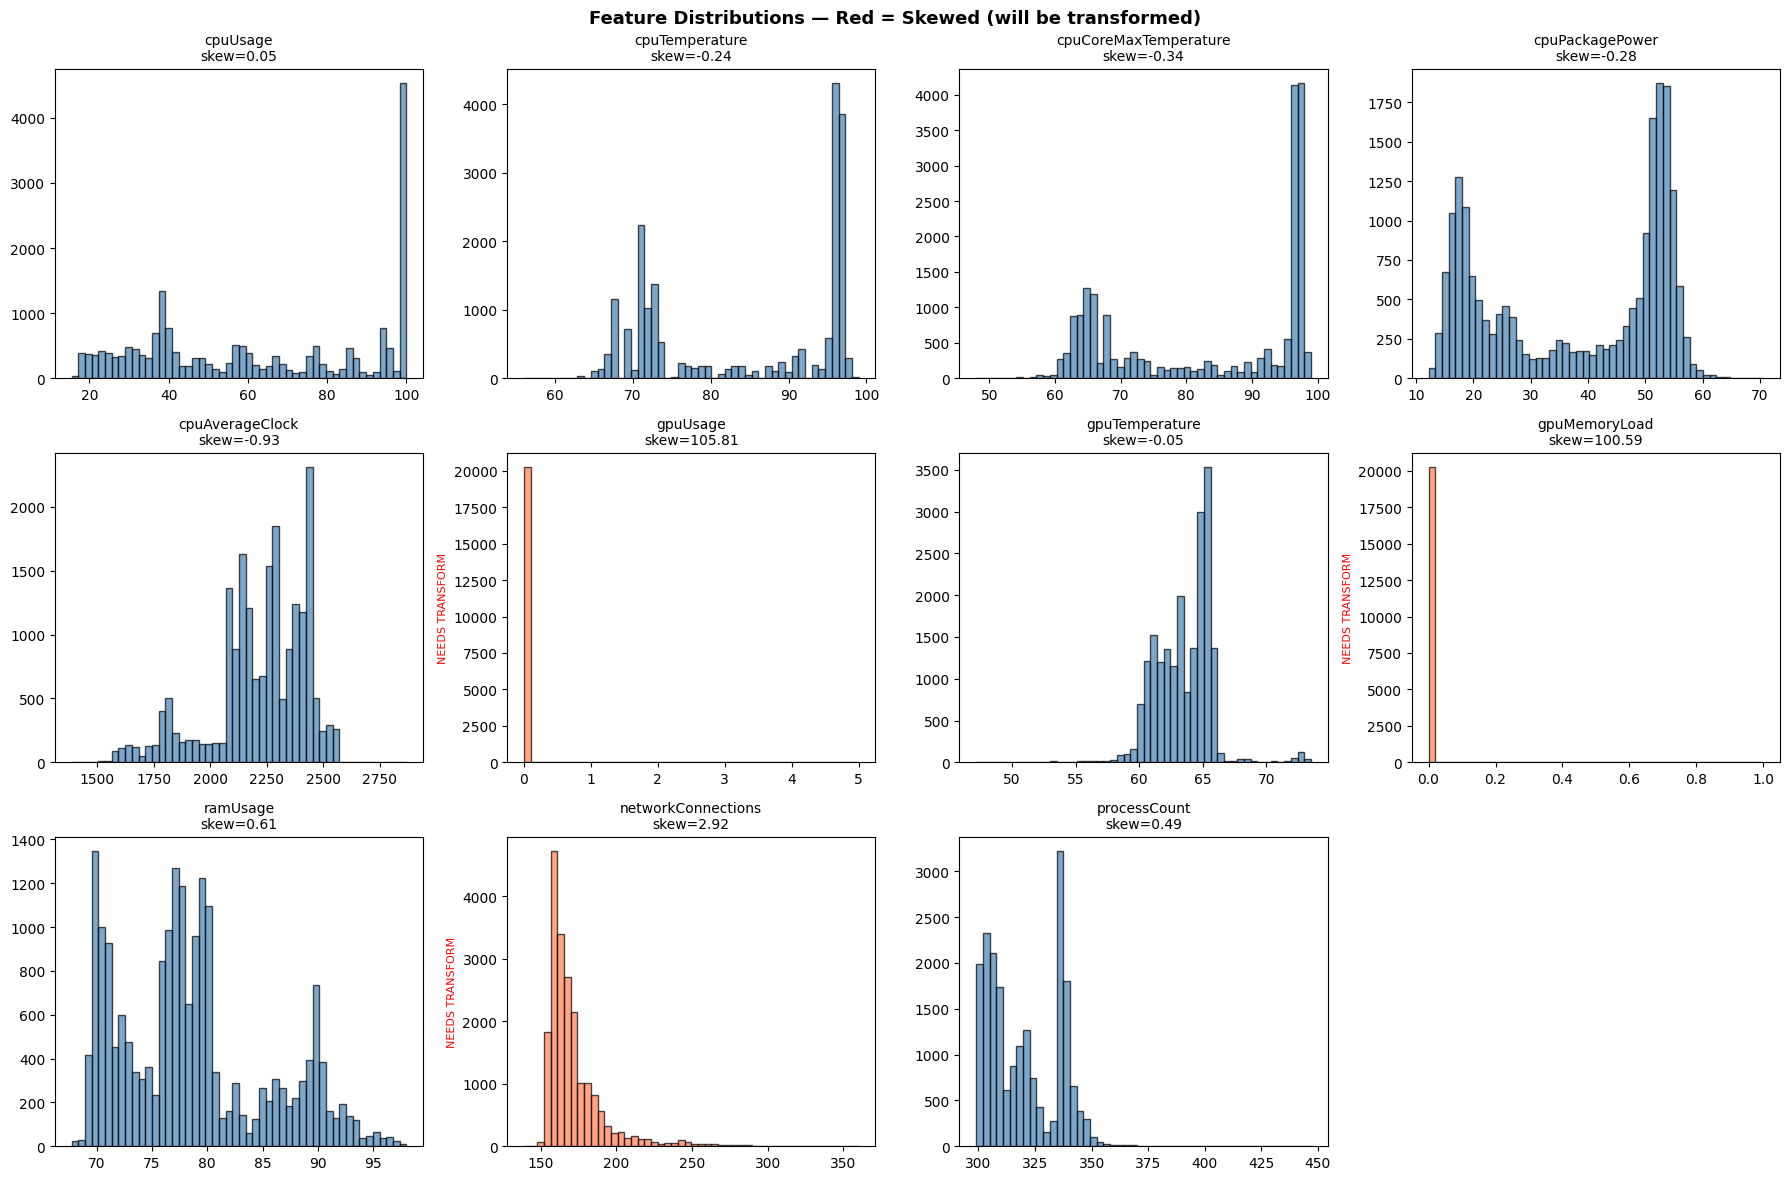

In [6]:
SKEW_THRESHOLD = 1.0

numeric_cols = df.select_dtypes(include='number').columns.tolist()
skewness = df[numeric_cols].skew()

print("=" * 55)
print(f"{'Column':<25} {'Skewness':>10} {'Transform?':>15}")
print("=" * 55)
for col in numeric_cols:
    sk = skewness[col]
    needs = "YES (Yeo-Johnson)" if abs(sk) > SKEW_THRESHOLD else "No"
    print(f"{col:<25} {sk:>10.4f} {needs:>15}")
print("=" * 55)

# Identify skewed columns
skewed_cols = [col for col in numeric_cols if abs(skewness[col]) > SKEW_THRESHOLD]
print(f"\nColumns requiring transformation: {skewed_cols}")

# Visualize distributions
import math

cols = 4
rows = math.ceil(len(numeric_cols) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()
# axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    ax = axes[i]
    ax.hist(df[col], bins=50, color='steelblue' if abs(skewness[col]) <= SKEW_THRESHOLD else 'coral',
            edgecolor='black', alpha=0.7)
    ax.set_title(f"{col}\nskew={skewness[col]:.2f}", fontsize=10)
    ax.set_xlabel('')
    if abs(skewness[col]) > SKEW_THRESHOLD:
        ax.set_ylabel('NEEDS TRANSFORM', color='red', fontsize=8)

# Hide unused subplot
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions — Red = Skewed (will be transformed)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Select Features and Target

We exclude the timestamp from training but keep data ordered sequentially.

In [7]:
feature_cols = ['cpuUsage', 'ramUsage', 'networkConnections', 'processCount', 'cpuPackagePower', 'cpuAverageClock']
target_col = 'cpuTemperature'

# Identify which features and target need transformation
skewed_features = [col for col in feature_cols if col in skewed_cols]
non_skewed_features = [col for col in feature_cols if col not in skewed_cols]
target_is_skewed = target_col in skewed_cols

print(f"Features (skewed, need Yeo-Johnson): {skewed_features}")
print(f"Features (symmetric, MinMaxScaler only): {non_skewed_features}")
print(f"Target '{target_col}' skewed: {target_is_skewed}")

Features (skewed, need Yeo-Johnson): ['networkConnections']
Features (symmetric, MinMaxScaler only): ['cpuUsage', 'ramUsage', 'processCount', 'cpuPackagePower', 'cpuAverageClock']
Target 'cpuTemperature' skewed: False


## 6. Data Preprocessing — Skewness-Aware Scaling

**Key improvement over the original notebook**: We split first, then fit transformers/scalers
**only on the training data** to prevent data leakage.

- Skewed features → Yeo-Johnson → MinMaxScaler
- Non-skewed features → MinMaxScaler only
- Skewed target → Yeo-Johnson → MinMaxScaler (invertible for predictions)

In [9]:
def preprocess_data(df, feature_cols, target_col, skewed_features, non_skewed_features,
                    target_is_skewed, train_ratio=0.8):
    """
    Preprocess data with skewness-aware transformations.
    Splits data FIRST, then fits transformers only on training portion.
    
    Returns:
        data_dict: Dictionary containing all processed data and fitted transformers
    """
    n = len(df)
    train_end = int(n * train_ratio)
    
    # Raw feature/target arrays
    X_raw = df[feature_cols].values
    y_raw = df[[target_col]].values
    
    # Split raw data
    X_train_raw = X_raw[:train_end]
    X_rest_raw = X_raw[train_end:]
    y_train_raw = y_raw[:train_end]
    y_rest_raw = y_raw[train_end:]
    
    # --- Process SKEWED features: Yeo-Johnson then MinMaxScaler ---
    transformers = {}
    
    if skewed_features:
        skewed_idx = [feature_cols.index(c) for c in skewed_features]
        
        pt_features = PowerTransformer(method='yeo-johnson')
        pt_features.fit(X_train_raw[:, skewed_idx])
        transformers['pt_features'] = pt_features
        
        X_train_skewed = pt_features.transform(X_train_raw[:, skewed_idx])
        X_rest_skewed = pt_features.transform(X_rest_raw[:, skewed_idx])
        
        scaler_skewed = MinMaxScaler(feature_range=(0, 1))
        scaler_skewed.fit(X_train_skewed)
        transformers['scaler_skewed'] = scaler_skewed
        
        X_train_skewed = scaler_skewed.transform(X_train_skewed)
        X_rest_skewed = scaler_skewed.transform(X_rest_skewed)
    
    # --- Process NON-SKEWED features: MinMaxScaler only ---
    if non_skewed_features:
        non_skewed_idx = [feature_cols.index(c) for c in non_skewed_features]
        
        scaler_normal = MinMaxScaler(feature_range=(0, 1))
        scaler_normal.fit(X_train_raw[:, non_skewed_idx])
        transformers['scaler_normal'] = scaler_normal
        
        X_train_normal = scaler_normal.transform(X_train_raw[:, non_skewed_idx])
        X_rest_normal = scaler_normal.transform(X_rest_raw[:, non_skewed_idx])
    
    # --- Reassemble features in original column order ---
    X_train_processed = np.zeros_like(X_train_raw, dtype=np.float64)
    X_rest_processed = np.zeros_like(X_rest_raw, dtype=np.float64)
    
    if skewed_features:
        for i, idx in enumerate(skewed_idx):
            X_train_processed[:, idx] = X_train_skewed[:, i]
            X_rest_processed[:, idx] = X_rest_skewed[:, i]
    
    if non_skewed_features:
        for i, idx in enumerate(non_skewed_idx):
            X_train_processed[:, idx] = X_train_normal[:, i]
            X_rest_processed[:, idx] = X_rest_normal[:, i]
    
    # --- Process TARGET ---
    if target_is_skewed:
        pt_target = PowerTransformer(method='yeo-johnson')
        pt_target.fit(y_train_raw)
        transformers['pt_target'] = pt_target
        
        y_train_transformed = pt_target.transform(y_train_raw)
        y_rest_transformed = pt_target.transform(y_rest_raw)
        
        scaler_y = MinMaxScaler(feature_range=(0, 1))
        scaler_y.fit(y_train_transformed)
        transformers['scaler_y'] = scaler_y
        
        y_train_processed = scaler_y.transform(y_train_transformed)
        y_rest_processed = scaler_y.transform(y_rest_transformed)
    else:
        scaler_y = MinMaxScaler(feature_range=(0, 1))
        scaler_y.fit(y_train_raw)
        transformers['scaler_y'] = scaler_y
        
        y_train_processed = scaler_y.transform(y_train_raw)
        y_rest_processed = scaler_y.transform(y_rest_raw)
    
    # Concatenate everything back
    X_all = np.vstack([X_train_processed, X_rest_processed])
    y_all = np.vstack([y_train_processed, y_rest_processed])
    
    return X_all, y_all, train_end, transformers


# Run preprocessing
X_processed, y_processed, train_end, transformers = preprocess_data(
    df, feature_cols, target_col, skewed_features, non_skewed_features, target_is_skewed
)

print(f"Processed features shape: {X_processed.shape}")
print(f"Processed target shape: {y_processed.shape}")
print(f"Training data ends at index: {train_end}")
print(f"\nStored transformers: {list(transformers.keys())}")

# Show before/after skewness for transformed columns
if skewed_features:
    skewed_idx = [feature_cols.index(c) for c in skewed_features]
    print(f"\n{'Column':<25} {'Before':>10} {'After':>10}")
    print("-" * 50)
    for feat, idx in zip(skewed_features, skewed_idx):
        before = df[feat].skew()
        after = pd.Series(X_processed[:train_end, idx]).skew()
        print(f"{feat:<25} {before:>10.4f} {after:>10.4f}")

if target_is_skewed:
    before = df[target_col].skew()
    after = pd.Series(y_processed[:train_end, 0]).skew()
    print(f"{target_col + ' (target)':<25} {before:>10.4f} {after:>10.4f}")

Processed features shape: (20239, 6)
Processed target shape: (20239, 1)
Training data ends at index: 16191

Stored transformers: ['pt_features', 'scaler_skewed', 'scaler_normal', 'scaler_y']

Column                        Before      After
--------------------------------------------------
networkConnections            2.9175     0.3305


## 7. Create Sliding Window Sequences

Each sample consists of `lookback` consecutive timesteps of features → predict next temperature.

In [11]:
def create_dataset(X_data, y_data, lookback=10):
    """Create sliding window sequences for time series prediction."""
    X, y = [], []
    for i in range(len(X_data) - lookback):
        X.append(X_data[i:i + lookback])
        y.append(y_data[i + lookback])
    return np.array(X), np.array(y)

print("Sequence creation function ready.")
print("Lookback window will be tuned by Optuna (range: 5-20).")

Sequence creation function ready.
Lookback window will be tuned by Optuna (range: 5-20).


## 8. Train / Validation / Test Split

**Key improvement**: Proper 3-way sequential split (80/10/10).
The original notebook used the test set as validation during training — we fix that here.

In [12]:
def prepare_data_loaders(X_processed, y_processed, train_end, lookback, batch_size):
    """
    Create sequences and split into train/val/test DataLoaders.
    The split respects the original train_end boundary from preprocessing.
    """
    # Create sequences from all processed data
    X_seq, y_seq = create_dataset(X_processed, y_processed, lookback=lookback)
    
    # Adjust train_end for the lookback offset
    # Sequences starting at index i use data[i:i+lookback], predicting data[i+lookback]
    # So sequence index (train_end - lookback) is the last sequence fully within training data
    adjusted_train_end = train_end - lookback
    
    # Split remaining into val and test (50/50)
    remaining = len(X_seq) - adjusted_train_end
    val_size = remaining // 2
    
    X_train = X_seq[:adjusted_train_end]
    y_train = y_seq[:adjusted_train_end]
    
    X_val = X_seq[adjusted_train_end:adjusted_train_end + val_size]
    y_val = y_seq[adjusted_train_end:adjusted_train_end + val_size]
    
    X_test = X_seq[adjusted_train_end + val_size:]
    y_test = y_seq[adjusted_train_end + val_size:]
    
    print(f"Lookback window: {lookback}")
    print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
    print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
    print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")
    
    # Convert to PyTorch tensors
    X_train_t = torch.FloatTensor(X_train).to(device)
    y_train_t = torch.FloatTensor(y_train).to(device)
    X_val_t = torch.FloatTensor(X_val).to(device)
    y_val_t = torch.FloatTensor(y_val).to(device)
    X_test_t = torch.FloatTensor(X_test).to(device)
    y_test_t = torch.FloatTensor(y_test).to(device)
    
    # Create DataLoaders
    train_dataset = TensorDataset(X_train_t, y_train_t)
    val_dataset = TensorDataset(X_val_t, y_val_t)
    test_dataset = TensorDataset(X_test_t, y_test_t)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader, X_test, y_test

print("Data loader preparation function ready.")

Data loader preparation function ready.


## 9. PyTorch LSTM Model Definition

**Architecture differences from the original Keras model:**
- Configurable number of LSTM layers (1–3, tuned by Optuna)
- Optional bidirectional LSTM
- PyTorch's native stacked LSTM with inter-layer dropout
- Single FC output head with dropout on the last hidden state

In [13]:
class LSTMPredictor(nn.Module):
    """
    LSTM-based regression model for CPU temperature prediction.
    
    Args:
        input_size: Number of input features per timestep
        hidden_size: Number of hidden units in each LSTM layer
        num_layers: Number of stacked LSTM layers
        dropout: Dropout rate applied between LSTM layers and before output
        bidirectional: Whether to use bidirectional LSTM
    """
    def __init__(self, input_size, hidden_size, num_layers, dropout, bidirectional=False):
        super(LSTMPredictor, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional
        )
        
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * self.num_directions, 1)
    
    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)
        # Initialize hidden states
        h0 = torch.zeros(self.num_layers * self.num_directions, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers * self.num_directions, x.size(0), self.hidden_size).to(x.device)
        
        # LSTM forward pass
        lstm_out, _ = self.lstm(x, (h0, c0))
        # lstm_out shape: (batch_size, seq_len, hidden_size * num_directions)
        
        # Take the output from the last timestep
        last_output = lstm_out[:, -1, :]
        
        # Apply dropout and pass through fully connected layer
        out = self.dropout(last_output)
        out = self.fc(out)
        return out

print("LSTMPredictor model class defined.")

LSTMPredictor model class defined.


## 10. Optuna Hyperparameter Optimization

We search over 8 hyperparameters with 30 trials. Each trial trains with:
- **Early stopping** (patience=7, monitoring validation loss)
- **Gradient clipping** (max\_norm=1.0)
- **LR Scheduler** (ReduceLROnPlateau)
- **Optuna pruning** (MedianPruner) to kill bad trials early

The objective is to minimize **validation MSE**.

In [16]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                n_epochs=100, patience=7, grad_clip=1.0, trial=None):
    """
    Train the model with early stopping and optional Optuna pruning.
    
    Returns:
        best_model_state: State dict of the best model (lowest val loss)
        train_losses: List of training losses per epoch
        val_losses: List of validation losses per epoch
    """
    best_val_loss = float('inf')
    best_model_state = None
    epochs_no_improve = 0
    train_losses = []
    val_losses = []
    
    for epoch in range(n_epochs):
        # ---- Training ----
        model.train()
        epoch_train_loss = 0.0
        n_train_batches = 0
        
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            loss.backward()
            
            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            
            optimizer.step()
            epoch_train_loss += loss.item()
            n_train_batches += 1
        
        avg_train_loss = epoch_train_loss / n_train_batches
        train_losses.append(avg_train_loss)
        
        # ---- Validation ----
        model.eval()
        epoch_val_loss = 0.0
        n_val_batches = 0
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                predictions = model(X_batch)
                loss = criterion(predictions, y_batch)
                epoch_val_loss += loss.item()
                n_val_batches += 1
        
        avg_val_loss = epoch_val_loss / n_val_batches
        val_losses.append(avg_val_loss)
        
        # LR Scheduler step
        scheduler.step(avg_val_loss)
        
        # Optuna pruning
        if trial is not None:
            trial.report(avg_val_loss, epoch)
            if trial.should_prune():
                raise TrialPruned()
        
        # Early stopping check
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break
    
    return best_model_state, train_losses, val_losses, best_val_loss


# def objective(trial):
#     """Optuna objective function — minimize validation MSE."""
    
#     # --- Sample hyperparameters ---
#     hidden_size = trial.suggest_categorical('hidden_size', [32, 64, 128])
#     num_layers = trial.suggest_int('num_layers', 1, 3)
#     dropout = trial.suggest_float('dropout', 0.1, 0.5, step=0.05)
#     lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
#     batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
#     lookback = trial.suggest_int('lookback_window', 5, 20)
#     weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
#     bidirectional = trial.suggest_categorical('bidirectional', [True, False])
    
#     # --- Prepare data with this lookback ---
#     train_loader, val_loader, _, _, _ = prepare_data_loaders(
#         X_processed, y_processed, train_end, lookback, batch_size
#     )
    
#     # --- Build model ---
#     input_size = X_processed.shape[1]  # number of features
#     model = LSTMPredictor(
#         input_size=input_size,
#         hidden_size=hidden_size,
#         num_layers=num_layers,
#         dropout=dropout,
#         bidirectional=bidirectional
#     ).to(device)
    
#     criterion = nn.MSELoss()
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
#     scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#         optimizer, mode='min', factor=0.5, patience=3, verbose=False
#     )
    
#     # --- Train ---
#     _, _, _, best_val_loss = train_model(
#         model, train_loader, val_loader, criterion, optimizer, scheduler,
#         n_epochs=100, patience=7, grad_clip=1.0, trial=trial
#     )
    
#     return best_val_loss


# # ---- Run Optuna Study ----
# print("Starting Optuna hyperparameter search (30 trials)...")
# print("This may take several minutes depending on GPU speed.\n")

# study = optuna.create_study(
#     direction='minimize',
#     sampler=optuna.samplers.TPESampler(seed=SEED),
#     pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)
# )

# study.optimize(objective, n_trials=30, show_progress_bar=True)

# # ---- Results ----
# print("\n" + "=" * 60)
# print("OPTUNA STUDY COMPLETE")
# print("=" * 60)
# print(f"Best trial value (val MSE): {study.best_value:.6f}")
# print(f"\nBest hyperparameters:")
# for key, value in study.best_params.items():
#     print(f"  {key:>20s}: {value}")
# print("=" * 60)

## 11. Train the Best Model

Rebuild and train the model using the best hyperparameters found by Optuna.
This time we train for more epochs with full early stopping and save the loss curves.

In [17]:
# Extract best hyperparameters
best_params = {
    "hidden_size": 64,
            "num_layers": 2,
               "dropout": 0.1,
         "learning_rate": 0.007791470666172783,
            "batch_size": 32,
       "lookback_window": 20,
          "weight_decay": 1.125026310986932e-06,
         "bidirectional": True
}
print("Training final model with best hyperparameters:")
for key, value in best_params.items():
    print(f"  {key}: {value}")

# Prepare data with best lookback
best_lookback = best_params['lookback_window']
best_batch_size = best_params['batch_size']

train_loader, val_loader, test_loader, X_test_np, y_test_np = prepare_data_loaders(
    X_processed, y_processed, train_end, best_lookback, best_batch_size
)

# Build model
input_size = X_processed.shape[1]
best_model = LSTMPredictor(
    input_size=input_size,
    hidden_size=best_params['hidden_size'],
    num_layers=best_params['num_layers'],
    dropout=best_params['dropout'],
    bidirectional=best_params['bidirectional']
).to(device)

# Print model summary
total_params = sum(p.numel() for p in best_model.parameters())
trainable_params = sum(p.numel() for p in best_model.parameters() if p.requires_grad)
print(f"\nModel Architecture:\n{best_model}")
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Setup training
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    best_model.parameters(),
    lr=best_params['learning_rate'],
    weight_decay=best_params['weight_decay']
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

# Train
print("\nTraining the final model...")
best_state, train_losses, val_losses, best_val = train_model(
    best_model, train_loader, val_loader, criterion, optimizer, scheduler,
    n_epochs=150, patience=10, grad_clip=1.0
)

# Restore best weights
best_model.load_state_dict(best_state)
print(f"\nTraining complete! Best validation MSE: {best_val:.6f}")
print(f"Trained for {len(train_losses)} epochs (early stopped).")

Training final model with best hyperparameters:
  hidden_size: 64
  num_layers: 2
  dropout: 0.1
  learning_rate: 0.007791470666172783
  batch_size: 32
  lookback_window: 20
  weight_decay: 1.125026310986932e-06
  bidirectional: True
Lookback window: 20
X_train: (16171, 20, 6), y_train: (16171, 1)
X_val:   (2024, 20, 6), y_val:   (2024, 1)
X_test:  (2024, 20, 6), y_test:  (2024, 1)

Model Architecture:
LSTMPredictor(
  (lstm): LSTM(6, 64, num_layers=2, batch_first=True, dropout=0.1, bidirectional=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

Total parameters: 136,321
Trainable parameters: 136,321

Training the final model...

Training complete! Best validation MSE: 0.003748
Trained for 67 epochs (early stopped).


### Training & Validation Loss Curves

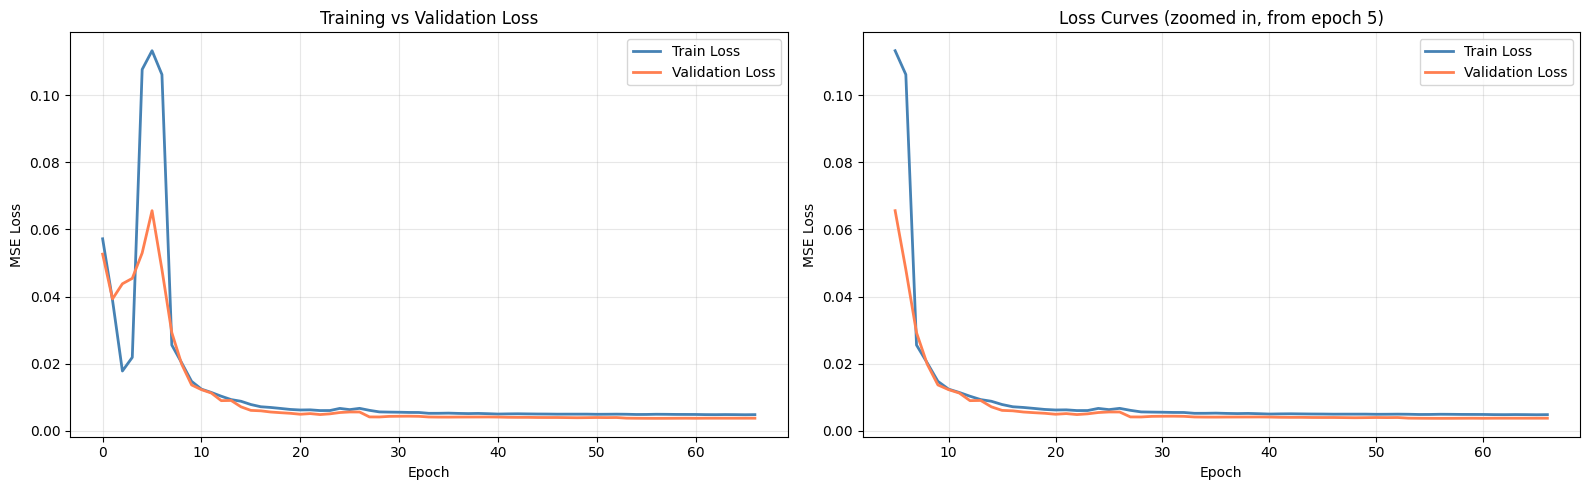

Final train loss: 0.004851
Final val loss:   0.003789
Gap: 21.9%
⚠️  Mild overfitting — consider increasing dropout or weight decay.


In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Full loss curves
ax1.plot(train_losses, label='Train Loss', color='steelblue', linewidth=2)
ax1.plot(val_losses, label='Validation Loss', color='coral', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.set_title('Training vs Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Zoomed in (skip first few epochs for clarity)
skip = min(5, len(train_losses) // 4)
ax2.plot(range(skip, len(train_losses)), train_losses[skip:], label='Train Loss', color='steelblue', linewidth=2)
ax2.plot(range(skip, len(val_losses)), val_losses[skip:], label='Validation Loss', color='coral', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MSE Loss')
ax2.set_title('Loss Curves (zoomed in, from epoch {})'.format(skip))
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Check for overfitting
final_train = train_losses[-1]
final_val = val_losses[-1]
if final_train > 0:
    gap = abs(final_val - final_train) / final_train * 100
else:
    gap = 0
print(f"Final train loss: {final_train:.6f}")
print(f"Final val loss:   {final_val:.6f}")
print(f"Gap: {gap:.1f}%")
if gap < 20:
    print("✅ No significant overfitting detected.")
elif gap < 50:
    print("⚠️  Mild overfitting — consider increasing dropout or weight decay.")
else:
    print("🔴 Significant overfitting detected — model may not generalize well.")

## 12. Evaluate on Test Set

Inverse-transform predictions back to original temperature scale and compute metrics.

In [20]:
def inverse_transform_target(y_scaled, transformers, target_is_skewed):
    """Inverse transform scaled predictions/actuals back to original scale."""
    scaler_y = transformers['scaler_y']
    y_unscaled = scaler_y.inverse_transform(y_scaled)
    
    if target_is_skewed:
        pt_target = transformers['pt_target']
        y_original = pt_target.inverse_transform(y_unscaled)
    else:
        y_original = y_unscaled
    
    return y_original


# Generate predictions on test set
best_model.eval()
all_preds = []
all_actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = best_model(X_batch)
        all_preds.append(preds.cpu().numpy())
        all_actuals.append(y_batch.cpu().numpy())

y_pred_scaled = np.vstack(all_preds)
y_test_scaled = np.vstack(all_actuals)

# Inverse transform to original scale
y_pred = inverse_transform_target(y_pred_scaled, transformers, target_is_skewed)
y_test_actual = inverse_transform_target(y_test_scaled, transformers, target_is_skewed)

# Compute metrics
mse = mean_squared_error(y_test_actual, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_actual, y_pred)
r2 = r2_score(y_test_actual, y_pred)

print("=" * 55)
print("         TEST SET PERFORMANCE")
print("=" * 55)
print(f"  Mean Absolute Error (MAE):       {mae:.2f} °C")
print(f"  Root Mean Squared Error (RMSE):  {rmse:.2f} °C")
print(f"  R² Score (Variance Explained):   {r2:.4f}")
print("=" * 55)

print("\n--- Comparison with Original Keras Model ---")
print(f"  {'Metric':<10} {'Original':>12} {'PyTorch':>12}")
print(f"  {'MAE':<10} {'2.00 °C':>12} {f'{mae:.2f} °C':>12}")
print(f"  {'RMSE':<10} {'5.09 °C':>12} {f'{rmse:.2f} °C':>12}")
print(f"  {'R²':<10} {'0.8076':>12} {f'{r2:.4f}':>12}")

         TEST SET PERFORMANCE
  Mean Absolute Error (MAE):       1.43 °C
  Root Mean Squared Error (RMSE):  2.49 °C
  R² Score (Variance Explained):   0.9290

--- Comparison with Original Keras Model ---
  Metric         Original      PyTorch
  MAE             2.00 °C      1.43 °C
  RMSE            5.09 °C      2.49 °C
  R²               0.8076       0.9290


## 13. Actual vs Predicted Temperature

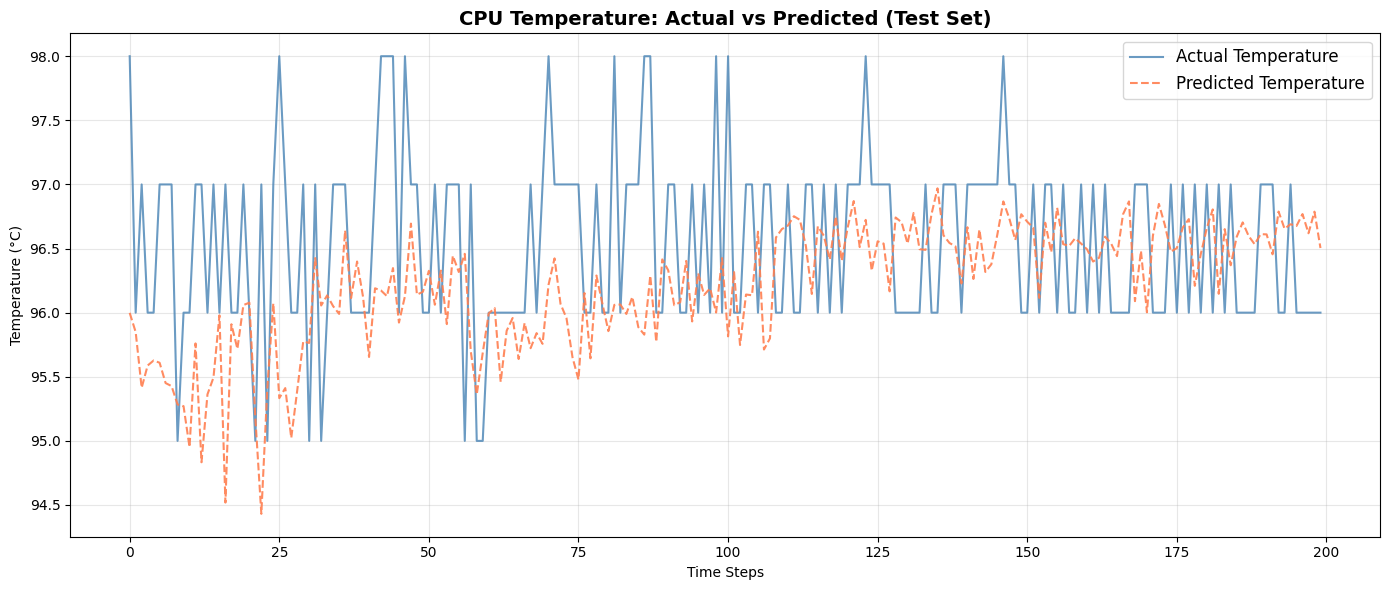

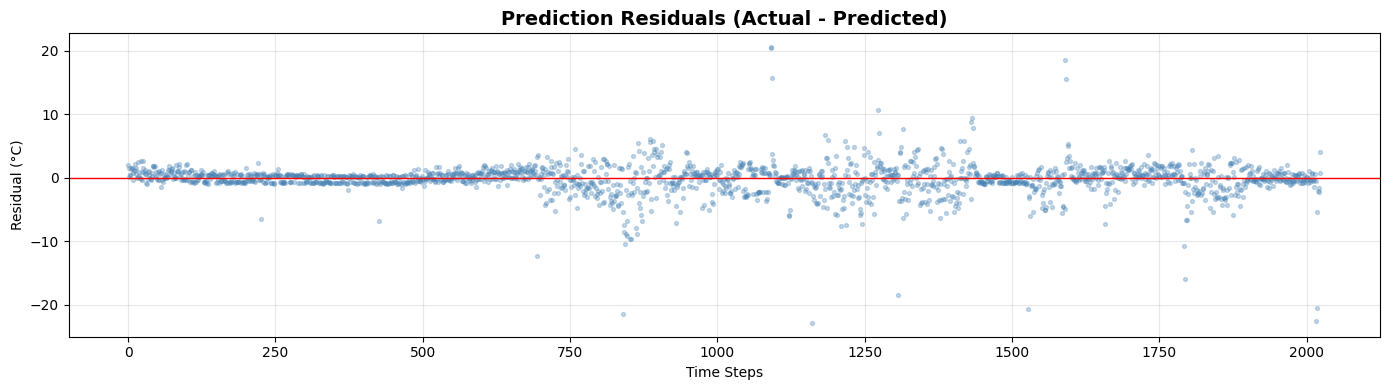

Residual stats: mean=-0.20°C, std=2.48°C


In [21]:
# Plot Actual vs Predicted (first 200 points)
n_plot = min(200, len(y_test_actual))

plt.figure(figsize=(14, 6))
plt.plot(y_test_actual[:n_plot], label='Actual Temperature', color='steelblue', alpha=0.8, linewidth=1.5)
plt.plot(y_pred[:n_plot], label='Predicted Temperature', color='coral', linestyle='--', alpha=0.9, linewidth=1.5)
plt.title('CPU Temperature: Actual vs Predicted (Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Time Steps')
plt.ylabel('Temperature (°C)')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Residual plot
residuals = y_test_actual.flatten() - y_pred.flatten()
plt.figure(figsize=(14, 4))
plt.scatter(range(len(residuals)), residuals, alpha=0.3, s=8, color='steelblue')
plt.axhline(y=0, color='red', linestyle='-', linewidth=1)
plt.title('Prediction Residuals (Actual - Predicted)', fontsize=14, fontweight='bold')
plt.xlabel('Time Steps')
plt.ylabel('Residual (°C)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Residual stats: mean={np.mean(residuals):.2f}°C, std={np.std(residuals):.2f}°C")

## 14. Cross-Hardware Generalization Test

Test the model trained on `prabhsimrat_logs.csv` on `manan_logs.csv` (different hardware).

Loaded manan_logs.csv: (20239, 12)

   PERFORMANCE ON MANAN'S LAPTOP (Cross-Hardware)
  Mean Absolute Error (MAE):       1.66 °C
  Root Mean Squared Error (RMSE):  2.84 °C
  R² Score (Variance Explained):   0.9446


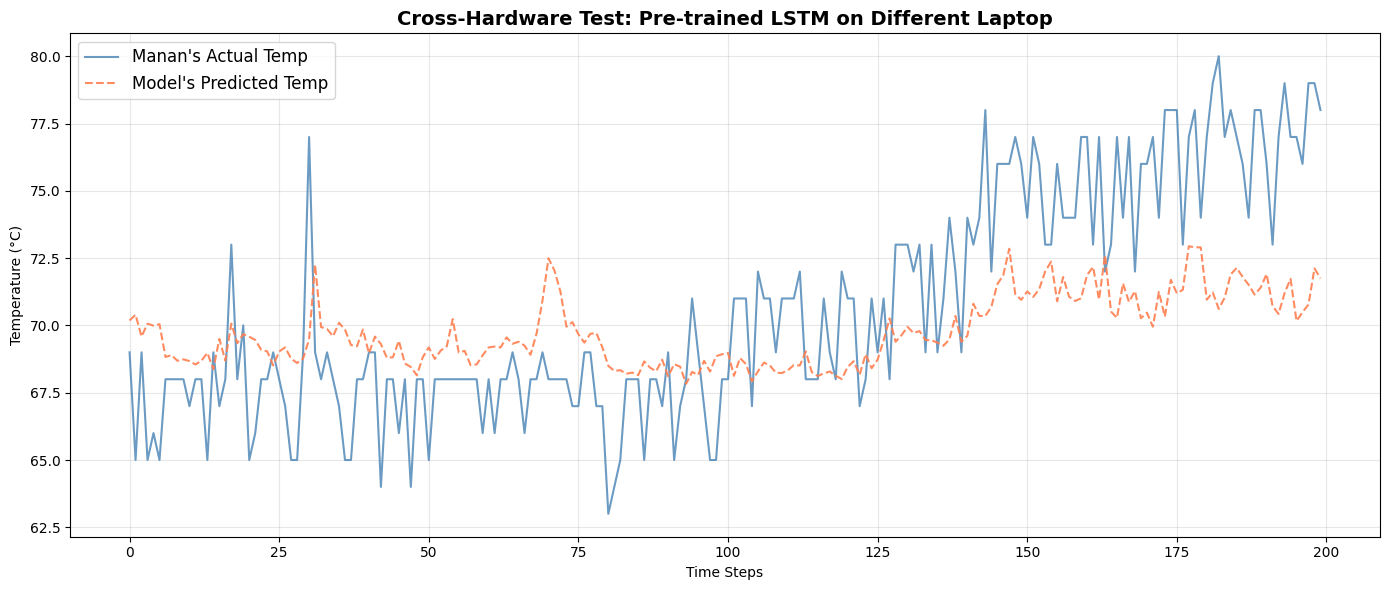

In [22]:
manan_csv = "manan_logs.csv"

if os.path.exists(manan_csv):
    df_manan = pd.read_csv(manan_csv)
    print(f"Loaded {manan_csv}: {df_manan.shape}")
    
    # Apply same preprocessing (transform only, no fitting!)
    X_manan_raw = df_manan[feature_cols].values
    y_manan_raw = df_manan[[target_col]].values
    
    # Process skewed features
    if skewed_features:
        skewed_idx = [feature_cols.index(c) for c in skewed_features]
        X_manan_skewed = transformers['pt_features'].transform(X_manan_raw[:, skewed_idx])
        X_manan_skewed = transformers['scaler_skewed'].transform(X_manan_skewed)
    
    # Process non-skewed features
    if non_skewed_features:
        non_skewed_idx = [feature_cols.index(c) for c in non_skewed_features]
        X_manan_normal = transformers['scaler_normal'].transform(X_manan_raw[:, non_skewed_idx])
    
    # Reassemble
    X_manan_processed = np.zeros_like(X_manan_raw, dtype=np.float64)
    if skewed_features:
        for i, idx in enumerate(skewed_idx):
            X_manan_processed[:, idx] = X_manan_skewed[:, i]
    if non_skewed_features:
        for i, idx in enumerate(non_skewed_idx):
            X_manan_processed[:, idx] = X_manan_normal[:, i]
    
    # Process target
    if target_is_skewed:
        y_manan_transformed = transformers['pt_target'].transform(y_manan_raw)
        y_manan_processed = transformers['scaler_y'].transform(y_manan_transformed)
    else:
        y_manan_processed = transformers['scaler_y'].transform(y_manan_raw)
    
    # Create sequences
    X_manan_seq, y_manan_seq = create_dataset(X_manan_processed, y_manan_processed, lookback=best_lookback)
    
    # Predict
    X_manan_t = torch.FloatTensor(X_manan_seq).to(device)
    best_model.eval()
    with torch.no_grad():
        y_pred_manan_scaled = best_model(X_manan_t).cpu().numpy()
    
    # Inverse transform
    y_pred_manan = inverse_transform_target(y_pred_manan_scaled, transformers, target_is_skewed)
    y_actual_manan = inverse_transform_target(y_manan_seq, transformers, target_is_skewed)
    
    # Metrics
    mse_m = mean_squared_error(y_actual_manan, y_pred_manan)
    rmse_m = np.sqrt(mse_m)
    mae_m = mean_absolute_error(y_actual_manan, y_pred_manan)
    r2_m = r2_score(y_actual_manan, y_pred_manan)
    
    print("\n" + "=" * 55)
    print("   PERFORMANCE ON MANAN'S LAPTOP (Cross-Hardware)")
    print("=" * 55)
    print(f"  Mean Absolute Error (MAE):       {mae_m:.2f} °C")
    print(f"  Root Mean Squared Error (RMSE):  {rmse_m:.2f} °C")
    print(f"  R² Score (Variance Explained):   {r2_m:.4f}")
    print("=" * 55)
    
    # Plot
    n_plot = min(200, len(y_actual_manan))
    plt.figure(figsize=(14, 6))
    plt.plot(y_actual_manan[:n_plot], label="Manan's Actual Temp", color='steelblue', alpha=0.8, linewidth=1.5)
    plt.plot(y_pred_manan[:n_plot], label="Model's Predicted Temp", color='coral', linestyle='--', alpha=0.9, linewidth=1.5)
    plt.title("Cross-Hardware Test: Pre-trained LSTM on Different Laptop", fontsize=14, fontweight='bold')
    plt.xlabel("Time Steps")
    plt.ylabel("Temperature (°C)")
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f"'{manan_csv}' not found. Skipping cross-hardware generalization test.")
    print("Place the file in the same directory to run this test.")

## 15. Save Model & Preprocessing Artifacts

In [24]:
# Save model
model_save_path = "best_lstm_model_pytorch.pth"
torch.save({
    'model_state_dict': best_model.state_dict(),
    'model_config': {
        'input_size': input_size,
        'hidden_size': best_params['hidden_size'],
        'num_layers': best_params['num_layers'],
        'dropout': best_params['dropout'],
        'bidirectional': best_params['bidirectional'],
    },
    'best_params': best_params,
    'best_val_loss': best_val,
}, model_save_path)
print(f"Model saved to: {model_save_path}")

# Save preprocessors
preprocessor_path = "preprocessors.pkl"
joblib.dump({
    'transformers': transformers,
    'feature_cols': feature_cols,
    'target_col': target_col,
    'skewed_features': skewed_features,
    'non_skewed_features': non_skewed_features,
    'target_is_skewed': target_is_skewed,
    'skew_threshold': SKEW_THRESHOLD,
}, preprocessor_path)
print(f"Preprocessors saved to: {preprocessor_path}")

# # Save Optuna study
# study_path = "optuna_study.pkl"
# joblib.dump(study, study_path)
# print(f"Optuna study saved to: {study_path}")

print("\n✅ All artifacts saved successfully!")

Model saved to: best_lstm_model_pytorch.pth
Preprocessors saved to: preprocessors.pkl

✅ All artifacts saved successfully!


## 16. Optuna Study Visualization

NameError: name 'study' is not defined

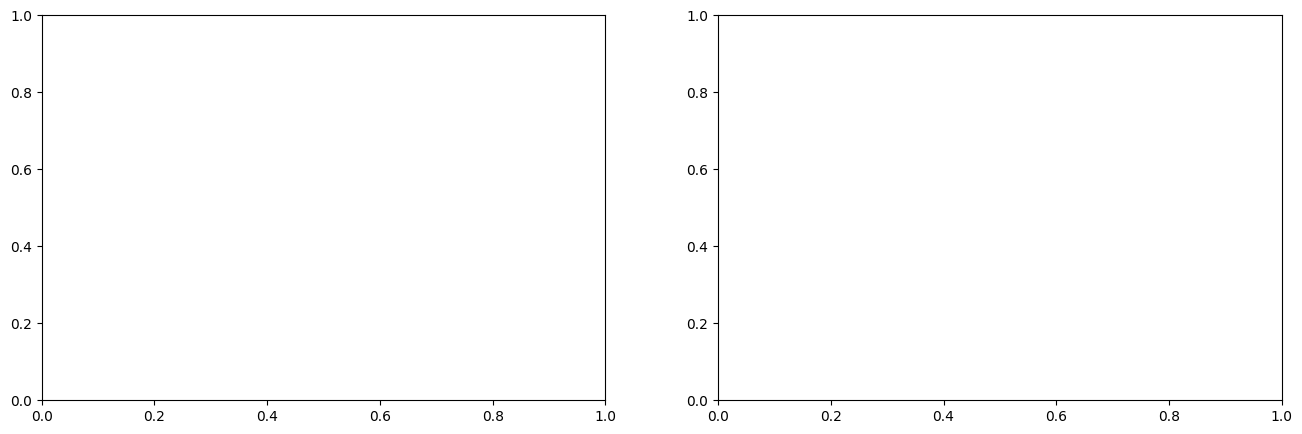

In [25]:
# Plot optimization history
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Trial values
trial_values = [t.value for t in study.trials if t.value is not None]
axes[0].plot(trial_values, marker='o', markersize=4, color='steelblue', alpha=0.7)
axes[0].axhline(y=study.best_value, color='red', linestyle='--', label=f'Best: {study.best_value:.6f}')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Validation MSE')
axes[0].set_title('Optuna Optimization History')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Hyperparameter importance (approximate using trial data)
param_names = list(study.best_params.keys())
importances = []
for param in param_names:
    values = [t.params.get(param) for t in study.trials if t.value is not None]
    objectives = [t.value for t in study.trials if t.value is not None]
    if all(isinstance(v, (int, float)) for v in values):
        corr = abs(np.corrcoef(values, objectives)[0, 1])
        importances.append(corr if not np.isnan(corr) else 0)
    else:
        importances.append(0)

sorted_idx = np.argsort(importances)[::-1]
axes[1].barh([param_names[i] for i in sorted_idx],
             [importances[i] for i in sorted_idx],
             color='steelblue', alpha=0.7)
axes[1].set_xlabel('|Correlation| with Objective')
axes[1].set_title('Approximate Hyperparameter Importance')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()